## Classical Baseline: HOG + SVM

### Approach
This uses a Histogram of Oriented Gradients (HOG) + Support Vector Machine (SVM) pipeline as a classical (non-deep) baseline. HOG captures local gradient structure and edge orientations in fixed-size image patches, making it a natural choice for symbol classification where shape is the primary distinguishing feature.

**Pipeline:**
1. Extract symbol crops from ground truth bounding boxes (64×64px, grayscale)
2. Cap at 500 samples per class to balance the dataset
3. Compute HOG features (9 orientations, 8×8 pixel cells, 2×2 block normalization)
4. Train a multi-class SVM with RBF kernel (C=10, gamma=scale)
5. Evaluate on an 80/20 train/validation split

Note: this is a classification baseline, not a full detection pipeline. It uses ground truth bounding boxes to extract crops, meaning it evaluates symbol classification ability in isolation, rather than the harder problem of finding symbols on the page that I will tackle in my cnn approach.

In [21]:
import sys
sys.path.insert(0, '/Users/samyu/obb_anns')

from obb_anns import OBBAnns
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import cv2
from skimage.feature import hog
from skimage import exposure
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns
from pathlib import Path

# Load annotations
train_anns = OBBAnns('../data/ds2_dense/deepscores_train.json')
train_anns.load_annotations()

test_anns = OBBAnns('../data/ds2_dense/deepscores_test.json')
test_anns.load_annotations()

# In-scope classes (from check-in 1)
IN_SCOPE = [
    'noteheadBlackOnLine', 'noteheadBlackInSpace',
    'noteheadHalfOnLine', 'noteheadHalfInSpace',
    'noteheadWholeOnLine', 'noteheadWholeInSpace',
    'ledgerLine', 'stem', 'beam',
    'flag8thDown', 'flag8thUp',
    'flag16thDown', 'flag16thUp',
    'restQuarter', 'restHalf', 'restWhole', 'rest8th',
    'clefG', 'clefF',
    'timeSig4', 'timeSig3', 'timeSig2', 'timeSigCommon', 'timeSigCutCommon',
    'accidentalSharp', 'accidentalFlat', 'accidentalNatural',
    'keySharp', 'keyFlat',
    'augmentationDot'
]

# Build category lookup: name -> cat_id and cat_id -> name (deepscores only)
deepscores_cats = {cat_id: cat for cat_id, cat in train_anns.cat_info.items()
                   if cat['annotation_set'] == 'deepscores'}
name_to_id = {cat['name']: cat_id for cat_id, cat in deepscores_cats.items()}
id_to_name = {str(cat_id): cat['name'] for cat_id, cat in deepscores_cats.items()}
in_scope_ids = {str(name_to_id[name]) for name in IN_SCOPE if name in name_to_id}

print(f"In-scope category IDs found: {len(in_scope_ids)}")
print(f"Categories loaded successfully")

loading ann_info...
done! t=5.16s
loading ann_info...
done! t=2.01s
In-scope category IDs found: 30
Categories loaded successfully


In [18]:
def extract_crops(ann_obj, img_dir, in_scope_ids, id_to_name,
                  target_size=(64, 64), max_per_class=500):
    crops = []
    labels = []
    class_counts = {}
    img_dir = Path(img_dir)
    img_lookup = {img['id']: img for img in ann_obj.img_info}
    img_cache = {}  # cache loaded images so we don't reload the same file repeatedly

    for _, ann in ann_obj.ann_info.iterrows():
        cat_id = ann['cat_id'][0]
        if cat_id not in in_scope_ids:
            continue
        class_name = id_to_name[cat_id]
        if class_counts.get(class_name, 0) >= max_per_class:
            continue
        bbox = ann['a_bbox']
        x0, y0, x1, y1 = int(bbox[0]), int(bbox[1]), int(bbox[2]), int(bbox[3])
        if x1 <= x0 or y1 <= y0:
            continue
        img_id = int(ann['img_id'])
        if img_id not in img_cache:
            img_info = img_lookup[img_id]
            img_path = img_dir / img_info['filename']
            try:
                img_cache[img_id] = np.array(Image.open(img_path).convert('L'))
            except Exception:
                img_cache[img_id] = None
        img = img_cache[img_id]
        if img is None:
            continue
        crop = img[y0:y1, x0:x1]
        if crop.size == 0:
            continue
        crop_resized = cv2.resize(crop, target_size)
        crops.append(crop_resized)
        labels.append(class_name)
        class_counts[class_name] = class_counts.get(class_name, 0) + 1

    return np.array(crops), np.array(labels)

In [19]:
print("Extracting training crops")
X_crops, y_labels = extract_crops(
    train_anns, 
    '../data/ds2_dense/images',
    in_scope_ids,
    id_to_name,
    target_size=(64, 64),
    max_per_class=500
)

print(f"Total crops extracted: {len(X_crops)}")
print(f"Unique classes: {len(np.unique(y_labels))}")
print(f"\nSamples per class:")
unique, counts = np.unique(y_labels, return_counts=True)
for cls, cnt in sorted(zip(unique, counts), key=lambda x: -x[1]):
    print(f"  {cls:<35} {cnt:>5}")

Extracting training crops
Total crops extracted: 14181
Unique classes: 30

Samples per class:
  accidentalFlat                        500
  accidentalNatural                     500
  accidentalSharp                       500
  augmentationDot                       500
  beam                                  500
  clefF                                 500
  clefG                                 500
  flag16thDown                          500
  flag16thUp                            500
  flag8thDown                           500
  flag8thUp                             500
  keyFlat                               500
  keySharp                              500
  ledgerLine                            500
  noteheadBlackInSpace                  500
  noteheadBlackOnLine                   500
  noteheadHalfInSpace                   500
  noteheadHalfOnLine                    500
  noteheadWholeInSpace                  500
  noteheadWholeOnLine                   500
  rest8th                 

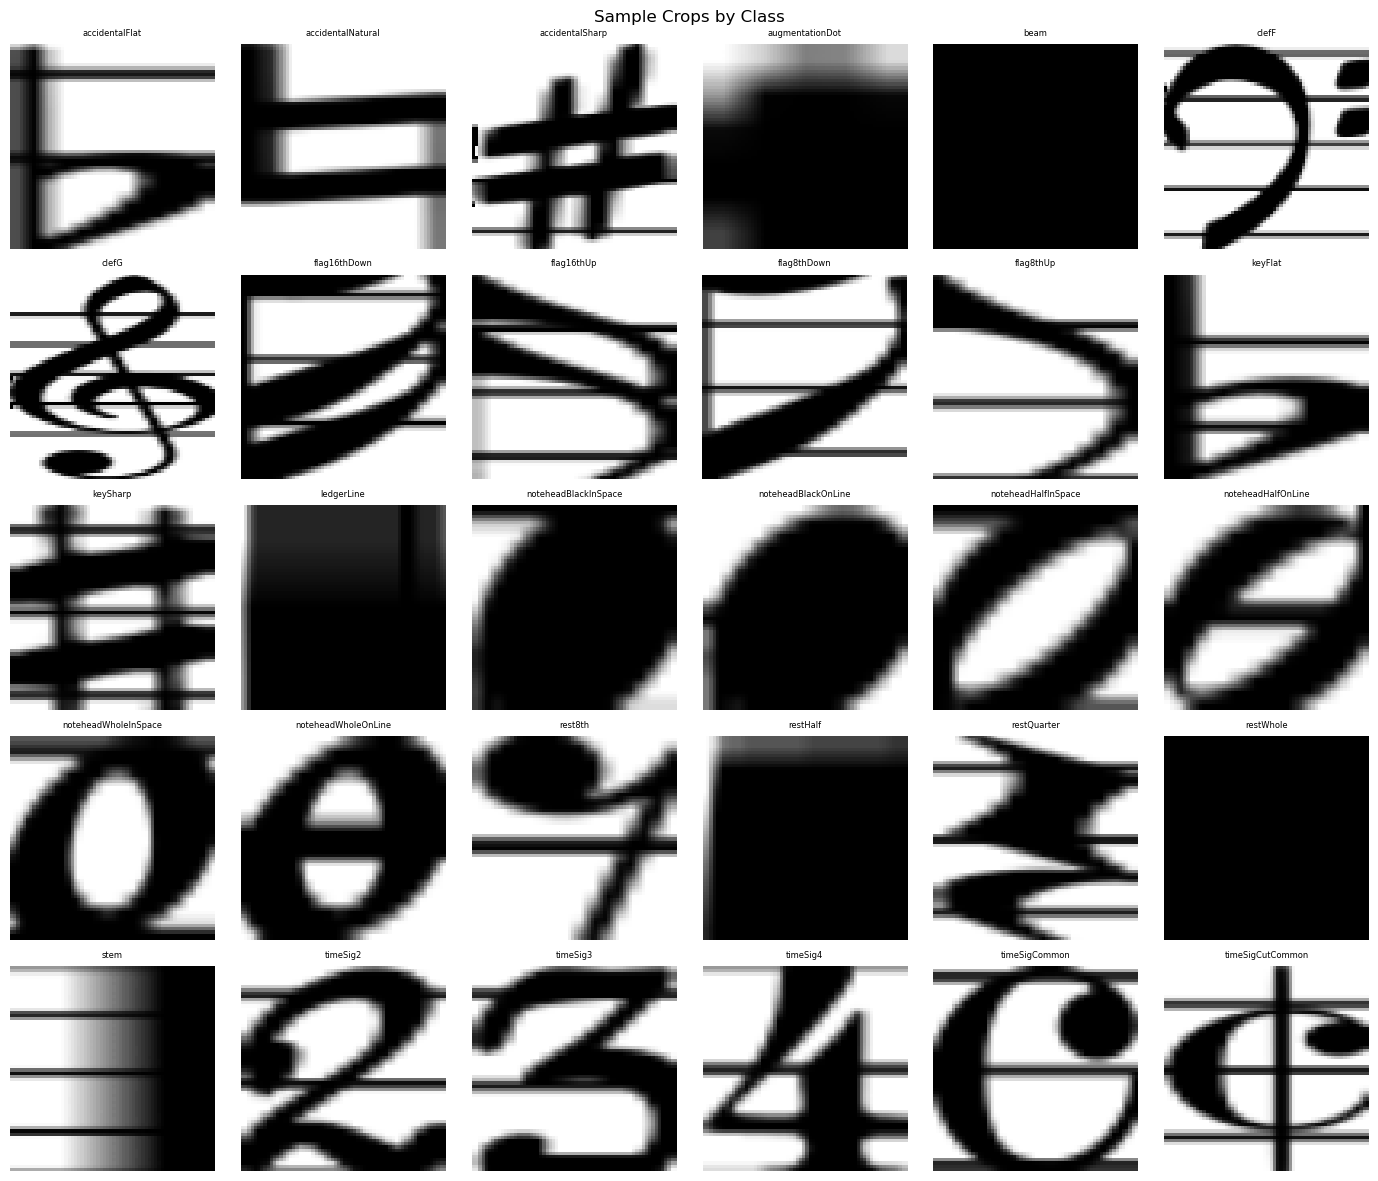

Computing HOG features...


Computing HOG features: 100%|██████████| 14181/14181 [00:08<00:00, 1770.40it/s]


HOG feature vector shape: (14181, 1764)


In [22]:
# Visualize a few sample crops per class to sanity check
fig, axes = plt.subplots(5, 6, figsize=(14, 12))
classes_to_show = list(np.unique(y_labels))[:30]

for ax, cls in zip(axes.flatten(), classes_to_show):
    idx = np.where(y_labels == cls)[0][0]
    ax.imshow(X_crops[idx], cmap='gray')
    ax.set_title(cls, fontsize=6)
    ax.axis('off')

plt.suptitle('Sample Crops by Class', fontsize=12)
plt.tight_layout()
plt.show()

# Compute HOG features
def compute_hog_features(crops):
    features = []
    for crop in tqdm(crops, desc='Computing HOG features'):
        fd = hog(crop, 
                 orientations=9,
                 pixels_per_cell=(8, 8),
                 cells_per_block=(2, 2),
                 visualize=False)
        features.append(fd)
    return np.array(features)

print("Computing HOG features...")
X_hog = compute_hog_features(X_crops)
print(f"HOG feature vector shape: {X_hog.shape}")

### Sample Crops
The crops above show clear visual distinctions between most classes. However, several observations suggest potential failure modes even before training:
- beam, stem, and ledgerLine are all thin rectangular shapes with minimal gradient structure --> HOG may struggle to distinguish them
- accidentalFlat and keyFlat are visually identical symbols (♭) in different musical contexts --> HOG has no contextual awareness to distinguish them
- Some crops appear to contain neighboring symbols bleeding in from adjacent bounding boxes, particularly for small symbols like augmentationDot and accidentalSharp

In [24]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)

# Train/val split (80/20) — keeping test set separate
X_train, X_val, y_train, y_val = train_test_split(
    X_hog, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

# Train SVM with RBF kernel
# StandardScaler is important for SVM performance
print("\nTraining SVM")
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale', 
                decision_function_shape='ovr'))
])

svm_pipeline.fit(X_train, y_train)

Training samples: 11344
Validation samples: 2837

Training SVM


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


Overall Accuracy: 0.9478 (94.78%)

                      precision    recall  f1-score   support

      accidentalFlat       0.89      0.76      0.82       100
   accidentalNatural       1.00      1.00      1.00       100
     accidentalSharp       0.88      0.85      0.86       100
     augmentationDot       1.00      1.00      1.00       100
                beam       0.96      0.70      0.81       100
               clefF       1.00      1.00      1.00       100
               clefG       1.00      1.00      1.00       100
        flag16thDown       1.00      1.00      1.00       100
          flag16thUp       1.00      1.00      1.00       100
         flag8thDown       1.00      1.00      1.00       100
           flag8thUp       1.00      1.00      1.00       100
             keyFlat       0.79      0.91      0.85       100
            keySharp       0.85      0.88      0.87       100
          ledgerLine       1.00      0.86      0.92       100
noteheadBlackInSpace       1.00   

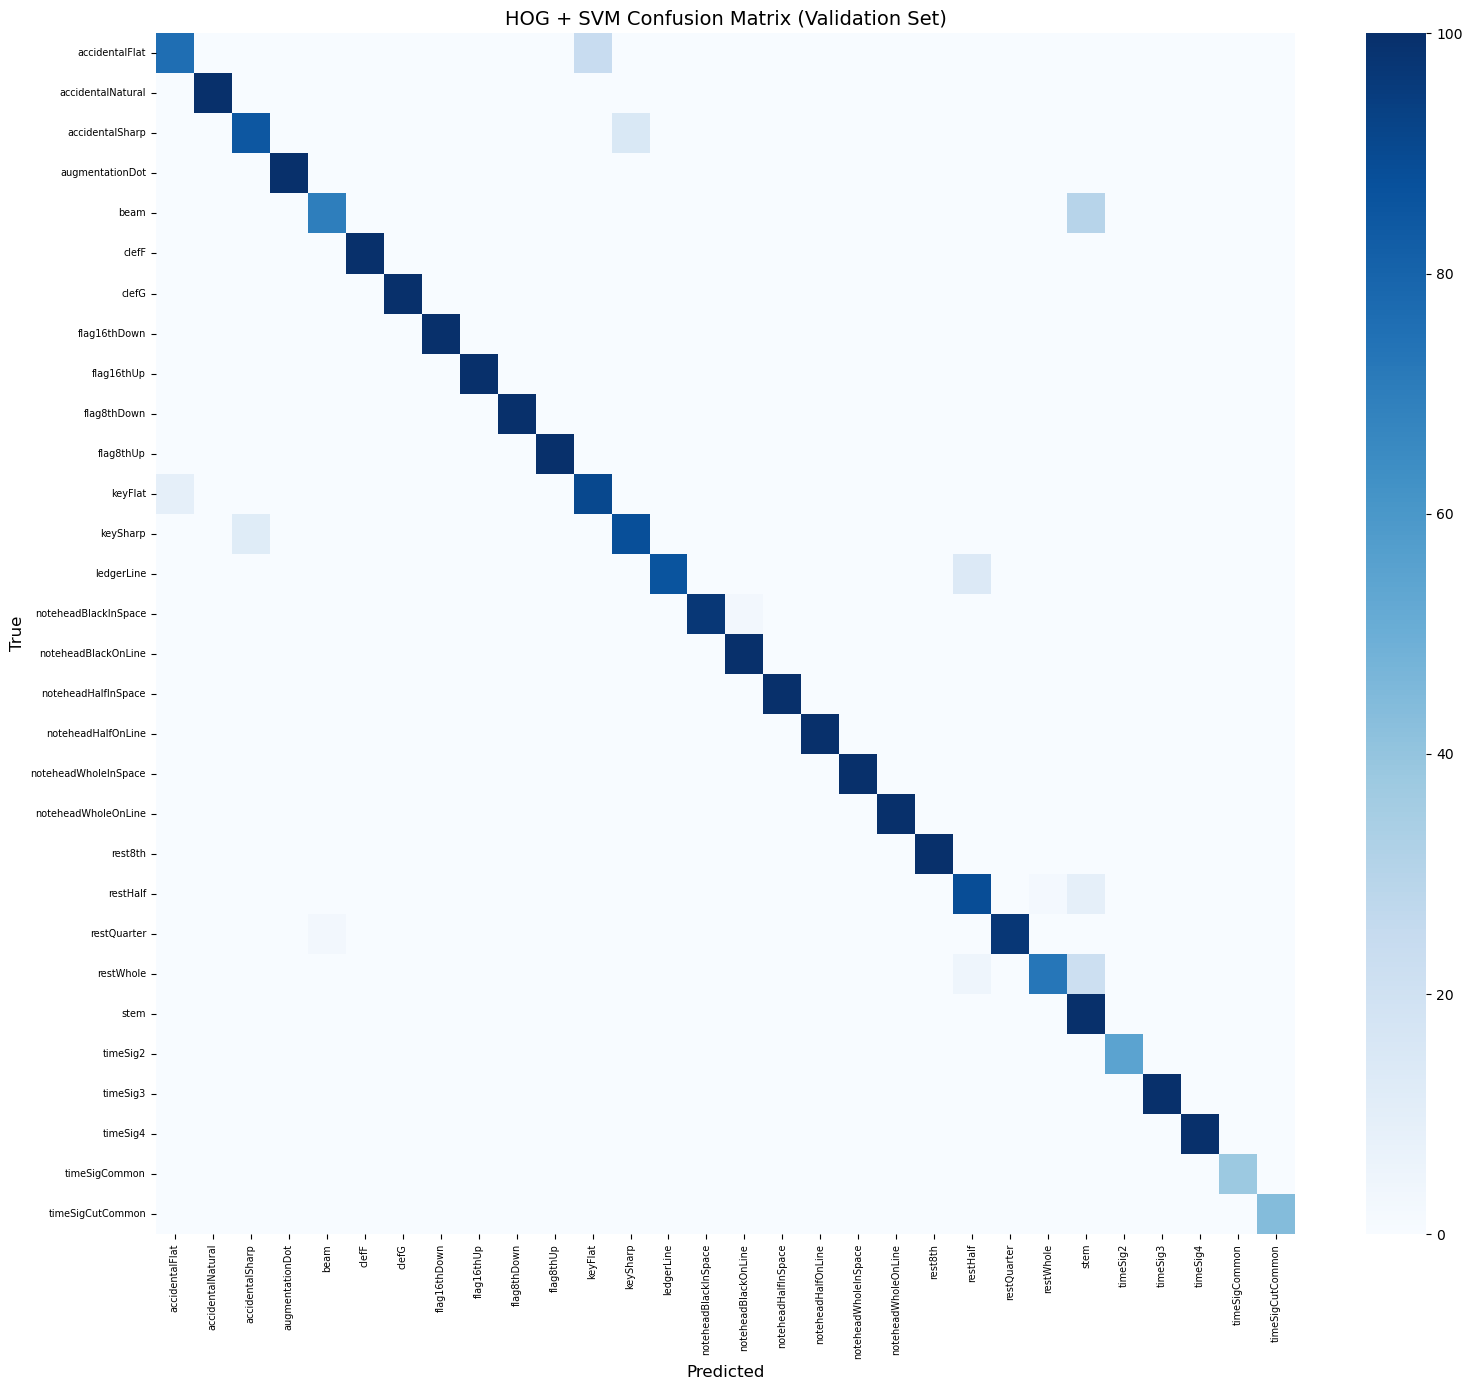

In [25]:
# Evaluate on validation set
y_pred = svm_pipeline.predict(X_val)

# Overall accuracy
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_val, y_pred)
print(f"Overall Accuracy: {acc:.4f} ({acc*100:.2f}%)\n")

# Per-class precision, recall, f1
class_names = le.classes_
print(classification_report(y_val, y_pred, target_names=class_names))

# Confusion matrix
fig, ax = plt.subplots(figsize=(16, 14))
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('HOG + SVM Confusion Matrix (Validation Set)', fontsize=14)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

### Results
Overall validation accuracy: 94.78%

Top performing classes (F1 = 1.00): accidentalNatural, augmentationDot, clefF, clefG, all flags, noteheadHalfOnLine/InSpace, noteheadWholeOnLine/InSpace, rest8th, all time signatures. These are visually distinctive symbols with consistent shapes that HOG captures well.

Weakest performing classes:
- stem (precision 0.62) — high recall but low precision, meaning many other symbols are being incorrectly predicted as stems
- beam (recall 0.70) — 30% of beams are missed, likely confused with stems
- restWhole (recall 0.73) — confused with stem and ledgerLine
- accidentalFlat / keyFlat — confused with each other as expected (same symbol)

### Confusion Matrix
The confusion matrix confirms the failure patterns identified above. The diagonal is strong for most classes. Notable off-diagonal concentrations:
- beam <--> stem
- restWhole --> stem
- ledgerLine --> restHalf
- accidentalFlat <--> keyFlat

Total misclassified: 148 / 2837


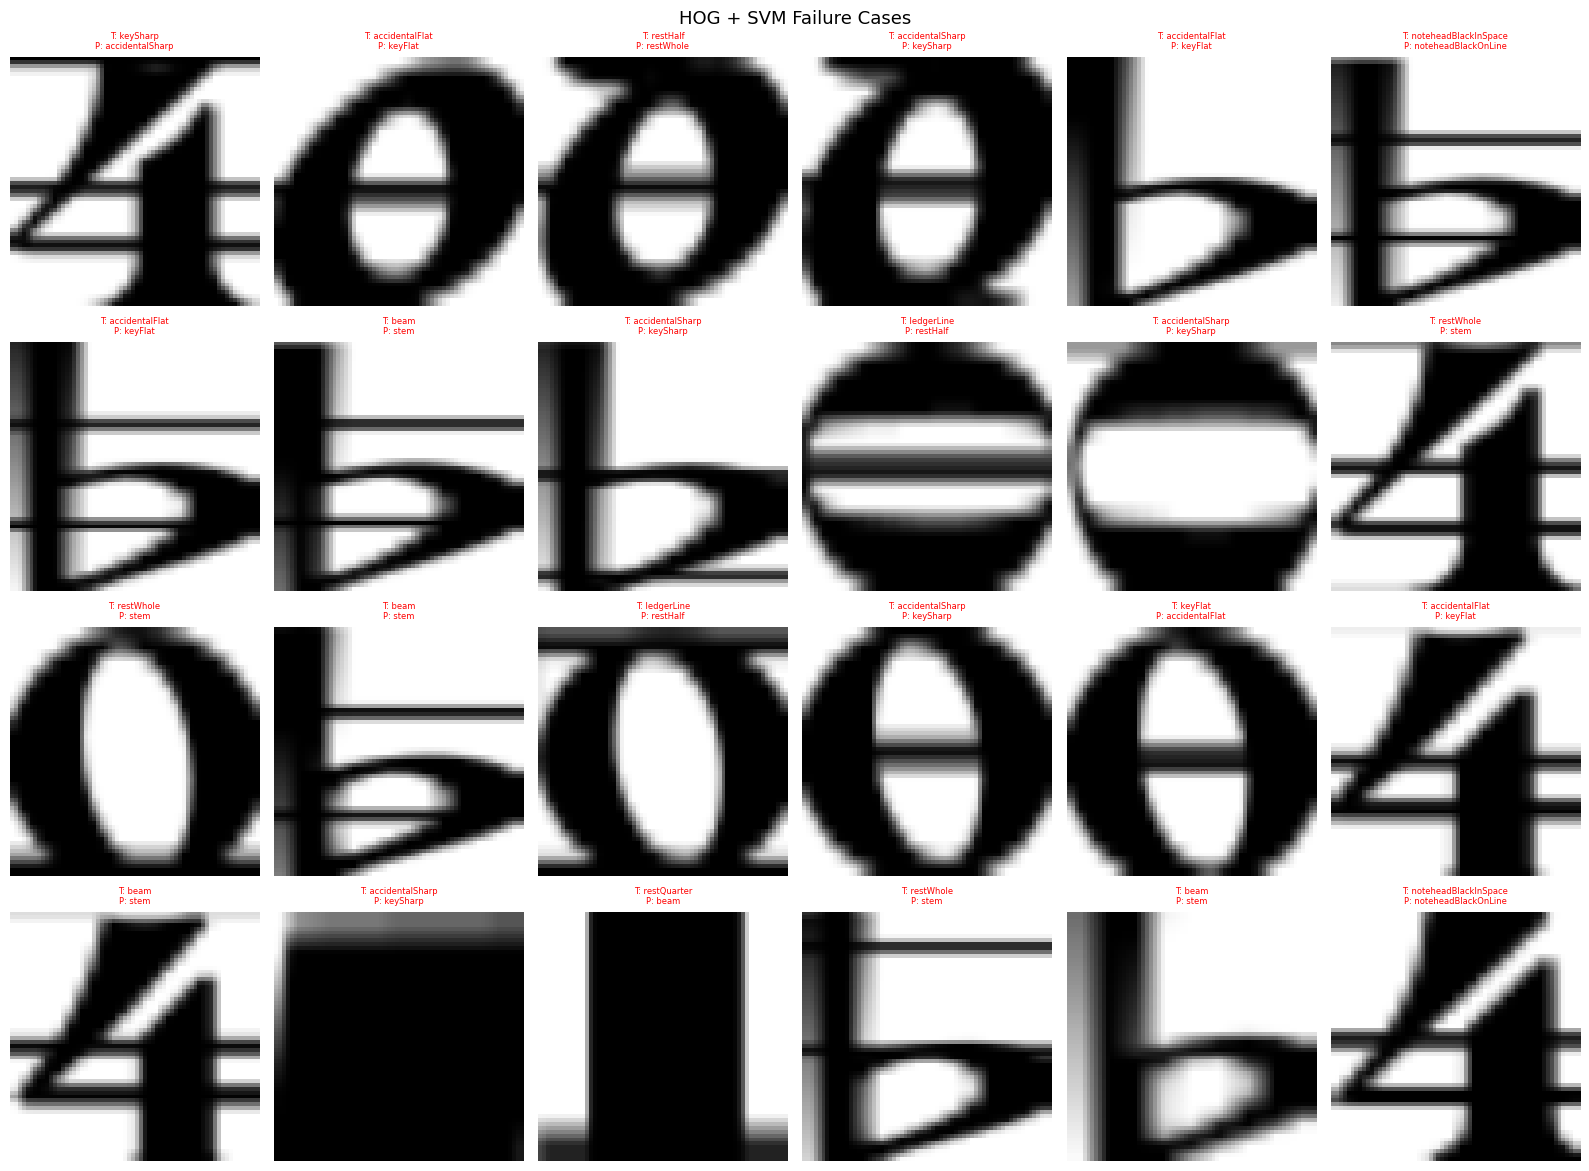

In [26]:
# Show failure cases
fig, axes = plt.subplots(4, 6, figsize=(16, 12))
axes = axes.flatten()

# Find misclassified samples
wrong_idx = np.where(y_pred != y_val)[0]
print(f"Total misclassified: {len(wrong_idx)} / {len(y_val)}")

# Show first 24 failures
for i, idx in enumerate(wrong_idx[:24]):
    ax = axes[i]
    ax.imshow(X_crops[len(X_train) + idx], cmap='gray')
    true_label = le.classes_[y_val[idx]]
    pred_label = le.classes_[y_pred[idx]]
    ax.set_title(f'T: {true_label}\nP: {pred_label}', 
                 fontsize=6, 
                 color='red')
    ax.axis('off')

# Hide unused axes
for i in range(len(wrong_idx[:24]), len(axes)):
    axes[i].axis('off')

plt.suptitle('HOG + SVM Failure Cases', fontsize=13)
plt.tight_layout()
plt.show()

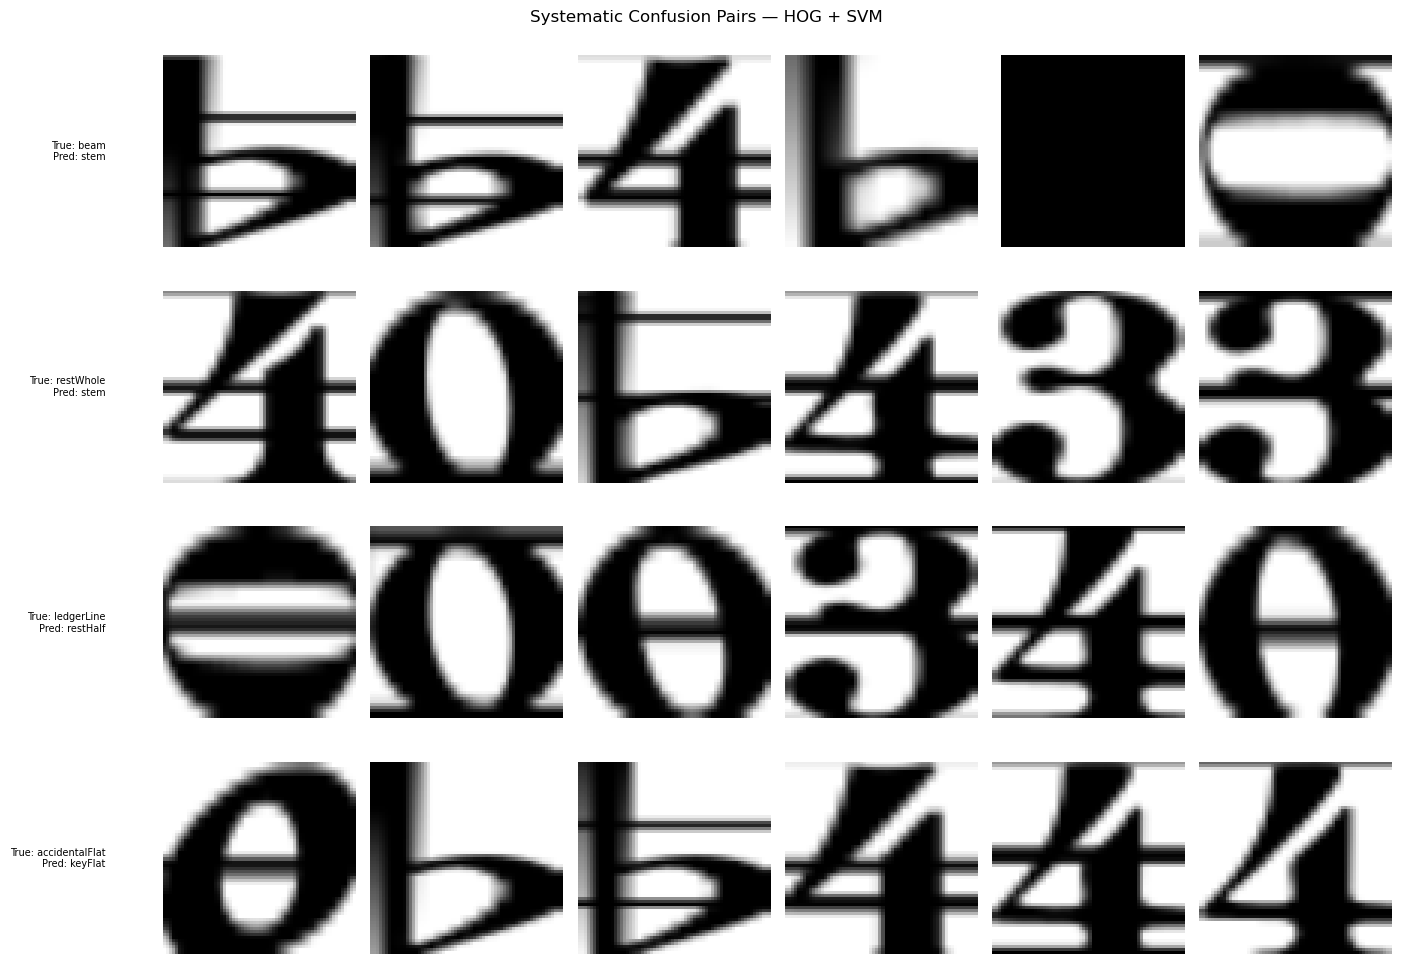

In [28]:
# Zoom in on stem vs beam vs ledgerLine confusion
confused_pairs = [
    ('beam', 'stem'),
    ('restWhole', 'stem'),
    ('ledgerLine', 'restHalf'),
    ('accidentalFlat', 'keyFlat'),
]

fig, axes = plt.subplots(len(confused_pairs), 6, figsize=(14, 10))

for row, (true_cls, pred_cls) in enumerate(confused_pairs):
    # Find cases where true=true_cls and pred=pred_cls
    true_enc = le.transform([true_cls])[0]
    pred_enc = le.transform([pred_cls])[0]
    
    confused_idx = np.where((y_val == true_enc) & (y_pred == pred_enc))[0]
    
    for col in range(6):
        ax = axes[row, col]
        if col < len(confused_idx):
            idx = confused_idx[col]
            ax.imshow(X_crops[len(X_train) + idx], cmap='gray')
            if col == 0:
                ax.text(-0.3, 0.5, f'True: {true_cls}\nPred: {pred_cls}',
                        transform=ax.transAxes,
                        fontsize=7, va='center', ha='right')
        ax.axis('off')

plt.suptitle('Systematic Confusion Pairs — HOG + SVM', fontsize=12)
plt.tight_layout()
plt.show()

### Failure Analysis

Three distinct failure patterns emerge from visual inspection of misclassified crops:

1. Bounding box context bleed
    Many failure crops contain neighboring symbols (e.g. a "4" appearing in a crop labeled as beam or restWhole). This occurs because bounding boxes in DeepScores V2 overlap heavily in dense orchestral scores. When a crop is extracted, it sometimes captures a neighboring symbol rather than the intended one. This is a fundamental limitation of crop-based classification on densely annotated music scores.

2. Thin symbol ambiguity
    beam, stem, ledgerLine, and restWhole are all thin rectangular shapes. When resized to 64×64, aspect ratio information is lost — a wide flat beam and a tall thin stem can produce very similar HOG gradient patterns. HOG without spatial context cannot reliably distinguish these classes.

3. Contextually identical glyphs
    accidentalFlat and keyFlat are the same visual symbol (♭). Their distinction is purely musical and contextual (i.e. a flat in a key signature vs. a flat next to a note). HOG has no access to this context, making confusion between them unavoidable without a higher-level understanding of the score layout.

Key takeaway: HOG+SVM performs surprisingly well (94.78%) on visually distinctive symbols but fails systematically on context-dependent and shape-similar classes. These are exactly the failure modes that motivate a deep learning approach with spatial awareness and learned feature hierarchies.